# Imports

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # project root for gates
os.chdir(os.path.abspath(".."))  # data/ paths resolve from project root
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import random

In [3]:
from gates.plotting import plot_fp_predictions

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import pandas as pd


In [4]:
from gates.data.load_data import load_flux_data, cut_flux_data
from gates.evaluation.post_processing import threshold_fps
import gates.evaluation.metrics as gates_metrics

## across region

478


/mnt/shared/home/kr21883/GATES_LPDM_emulator/gates/plotting/plotting_predictions.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  


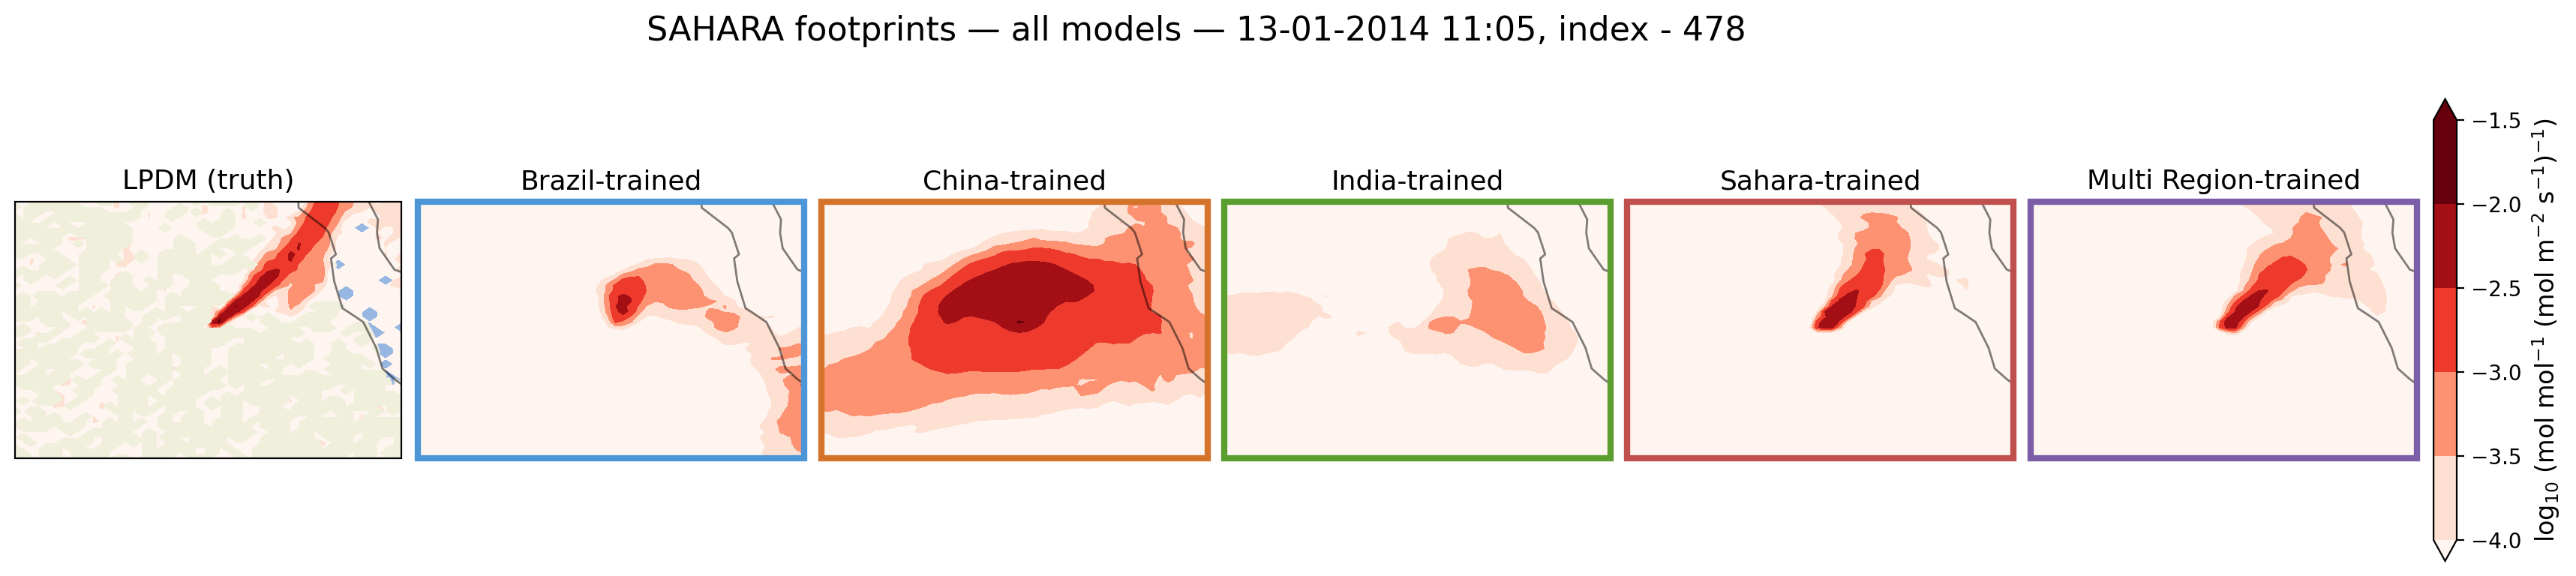

In [52]:
from gates.plotting import plot_multi_model_predictions

index_to_plot = random.randint(0, 10000)
#index_to_plot = 1000
print(index_to_plot)
# All 5 models tested
fig, ax = plot_multi_model_predictions(
    test_region="SAHARA",
    idx=index_to_plot,
    save=True,
    filename=f"sahara_all_models_idx{index_to_plot}_300dpi.png",
)

In [83]:
def plot_regional_fps(model_region, test_region, idxs_list=None, contour=True, thres=1e-4):
    if model_region == "MULTI_REGION":
        pred_dir = f"model_test_predictions/{model_region.lower()}_model/sahara_india_china_brazil_multiregion_proper/predictions_{test_region}"
    elif model_region != "INDIA":
        pred_dir = f"model_test_predictions/{model_region.lower()}_model/{model_region}_proper/predictions_{test_region}"
    else:
        pred_dir = f"model_test_predictions/{model_region.lower()}_model/{model_region}_proper_train_freq_2_test_freq_25/predictions_{test_region}"
    print(pred_dir)
    preds = xr.open_mfdataset(glob.glob(f"/mnt/shared/home/kr21883/GATES_LPDM_emulator/{pred_dir}/predictions_2014_*.nc"))
    preds = threshold_fps(preds, threshold=1.75e-5)
    if idxs_list is None:
        ints_to_plot = random.sample(list(range(len(preds.time.values))), 4)
    else:        ints_to_plot = [10, 100, 200, 240]
    print(ints_to_plot)
    plot_fp_predictions(preds, idxs_list=ints_to_plot, contour=contour, thres=thres, fig_title=f"{test_region} footprints predicted with a {model_region}-trained model", which_dataspace="original")

model_test_predictions/brazil_model/BRAZIL_proper/predictions_BRAZIL
[16007, 14483, 7661, 16354]
[1, 1]


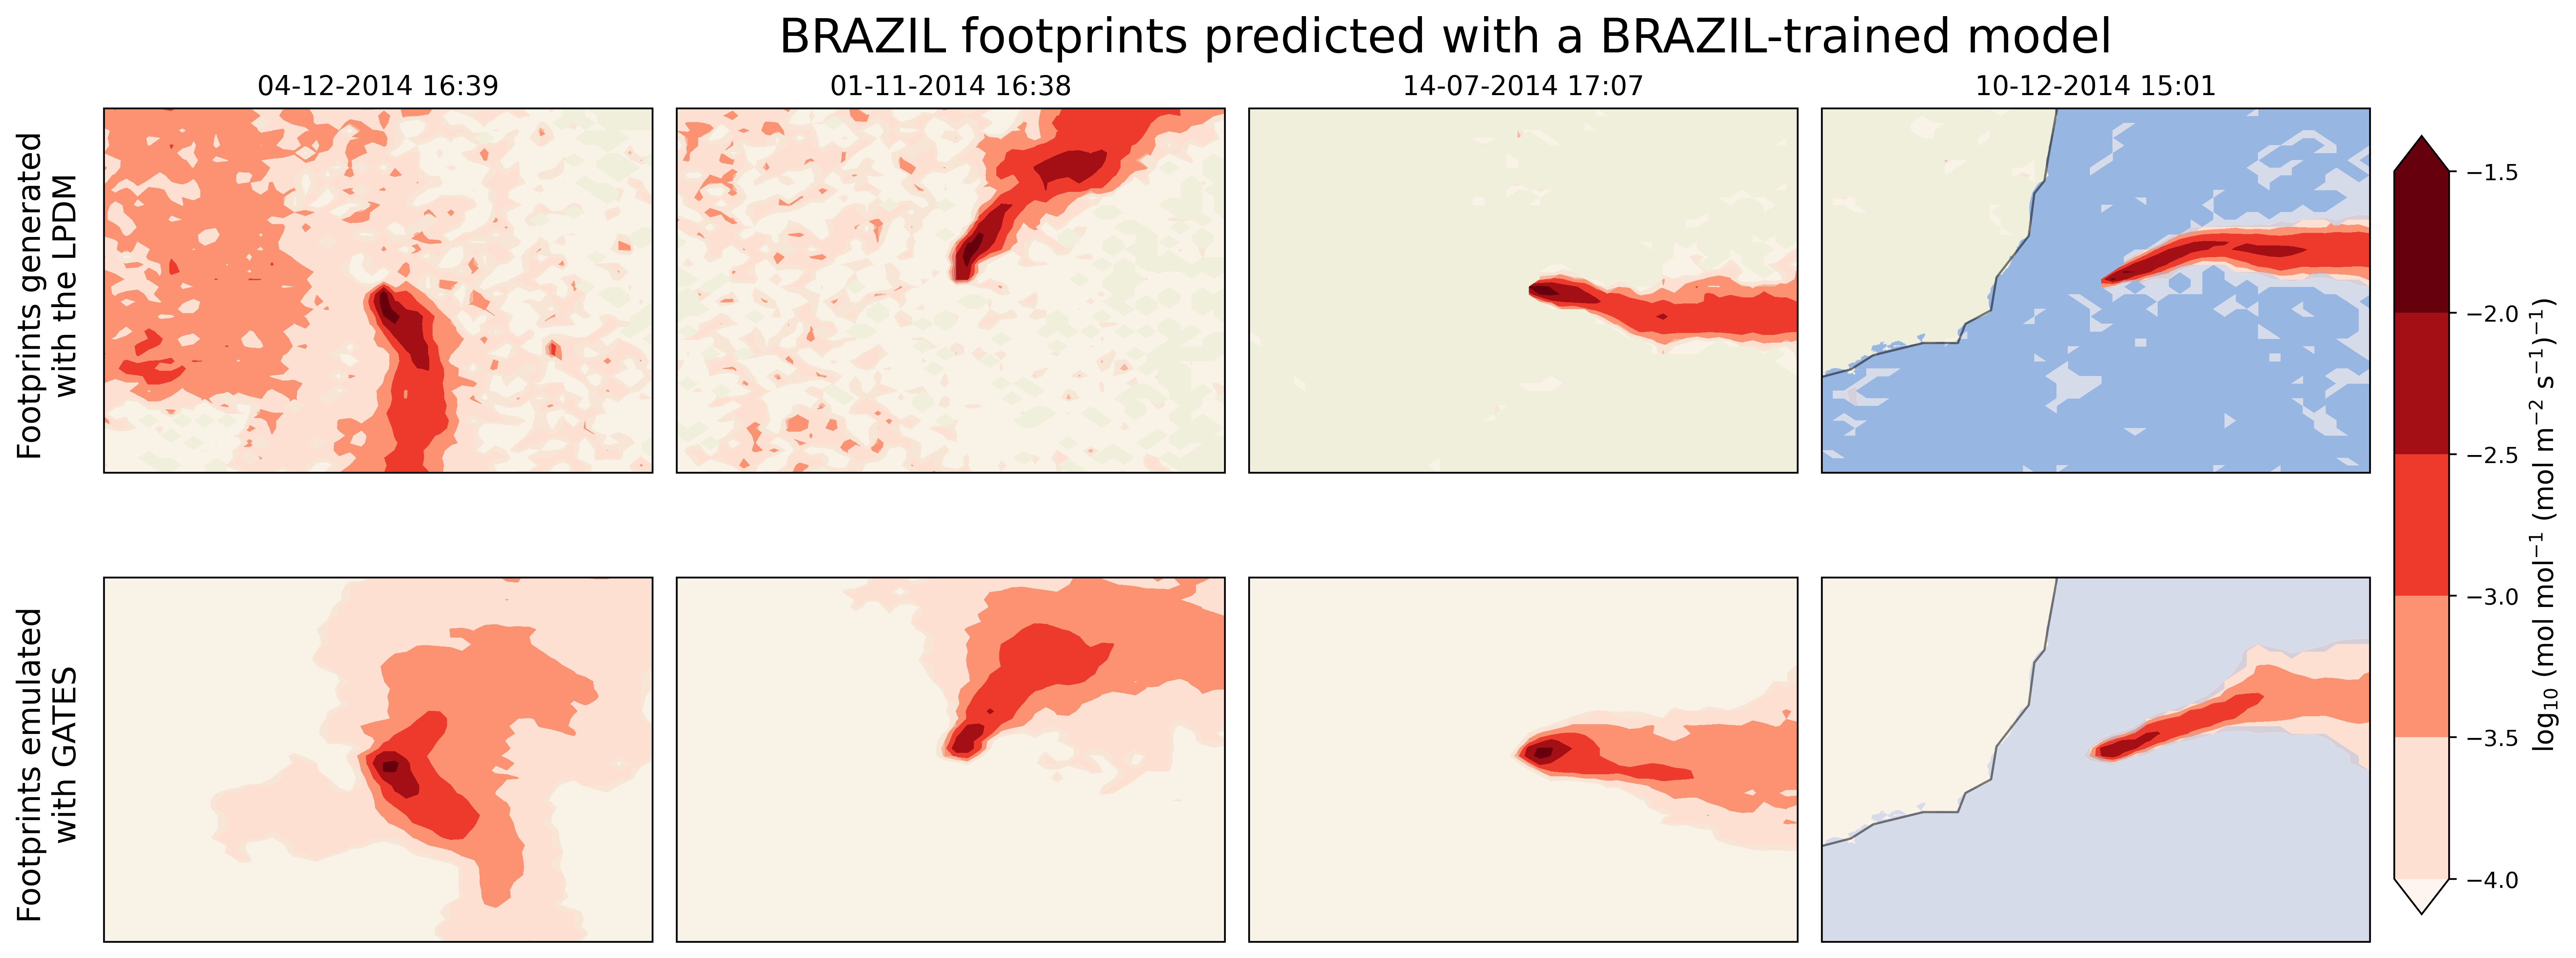

In [20]:
plot_regional_fps("BRAZIL", "BRAZIL", #idxs_list=index_to_plot
    )

model_test_predictions/multi_region_model/sahara_india_china_brazil_multiregion_proper/predictions_SAHARA
[8616, 10302, 7051, 1757]
[1, 1]


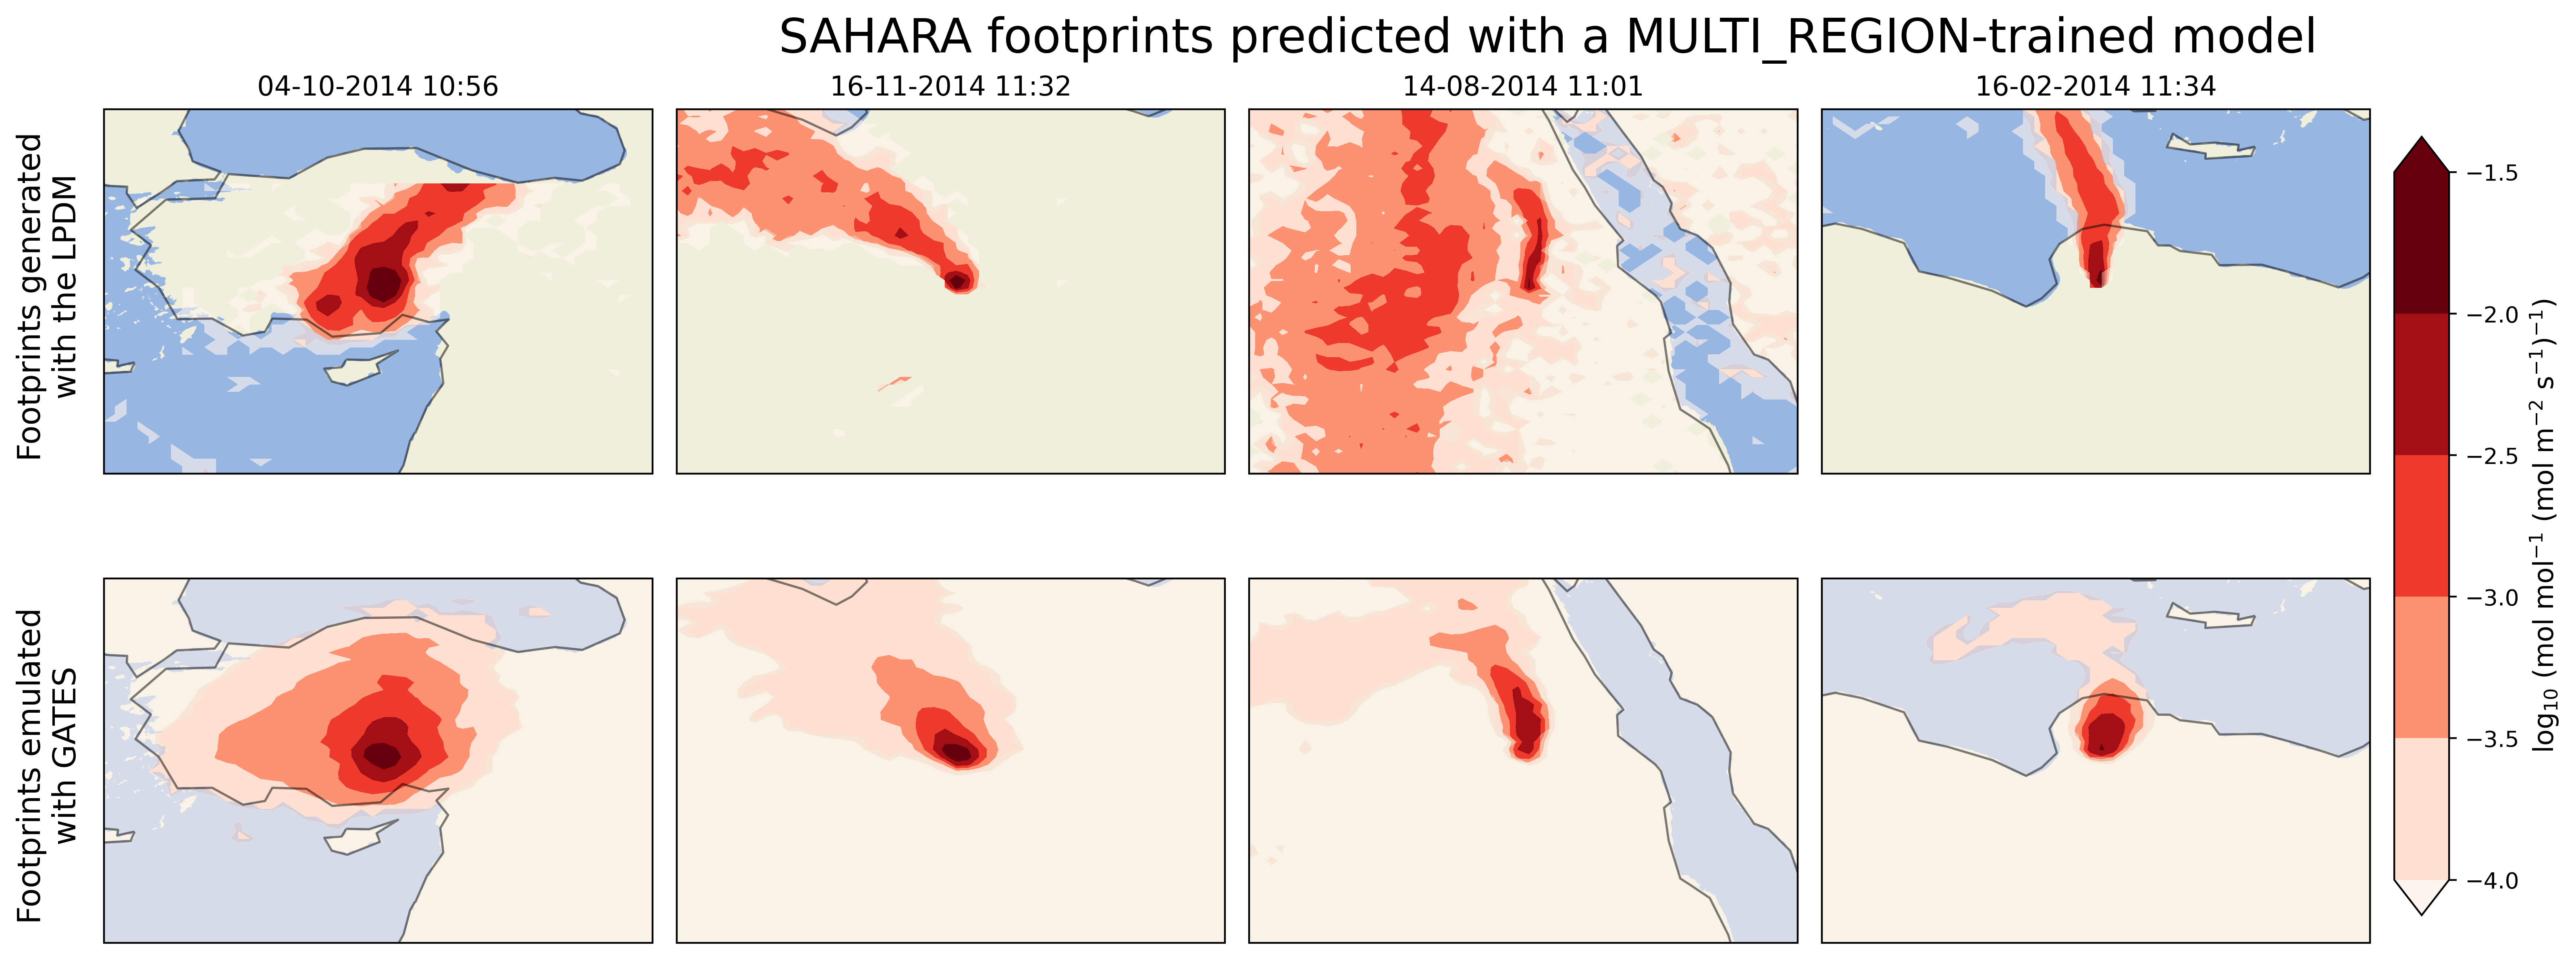

In [19]:
plot_regional_fps("MULTI_REGION", "SAHARA")

In [ ]:
plot_regional_fps("BRAZIL", "CHINA")

In [ ]:
plot_regional_fps("CHINA", "BRAZIL")

In [ ]:
plot_regional_fps("SAHARA", "BRAZIL")

In [ ]:
plot_regional_fps("INDIA", "BRAZIL")

In [ ]:
plot_regional_fps("BRAZIL", "SAHARA")

In [ ]:
plot_regional_fps("CHINA", "SAHARA")

In [ ]:
plot_regional_fps("INDIA", "SAHARA")

In [ ]:
plot_regional_fps("INDIA", "INDIA")

In [ ]:
plot_regional_fps("BRAZIL", "INDIA")

In [ ]:
plot_regional_fps("CHINA", "INDIA")

In [ ]:
plot_regional_fps("SAHARA", "INDIA")

In [ ]:
plot_regional_fps("CHINA", "CHINA")

In [ ]:
plot_regional_fps("BRAZIL", "CHINA")

In [ ]:
plot_regional_fps("INDIA", "CHINA")

In [ ]:
plot_regional_fps("SAHARA", "CHINA")

# Brazil

# China

# India

# Sahara

In [ ]:
preds = xr.open_mfdataset(glob.glob("/mnt/shared/home/kr21883/GATES_LPDM_emulator/model_test_predictions/sahara_model/SAHARA_proper/predictions_SAHARA/predictions_2014_*.nc"))
preds = threshold_fps(preds, threshold=1.75e-5)

In [ ]:
ints_to_plot = random.sample(list(range(len(preds.time.values))), 4)
print(ints_to_plot)

In [ ]:
plot_fp_predictions(preds, idxs_list=ints_to_plot, contour=True, thres=1e-4, fig_title="Sahara footprints predicted with a Sahara-trained model", which_dataspace="original")

# Metrics for whole test set year

In [10]:
# Point to each predictions folder
#pred_dir = "model_test_predictions/india_model/INDIA_proper_train_freq_2_test_freq_25/predictions_BRAZIL"
#pred_dir = "model_test_predictions/sahara_model/SAHARA_proper/predictions_BRAZIL"
#pred_dir = "model_test_predictions/china_model/CHINA_proper/predictions_BRAZIL"

#pred_dir = "model_test_predictions/multi_region_model_341_fullrun/sahara_india_china_brazil_multiregion_proper/predictions_INDIA"

#pred_dir = "model_test_predictions/multi_region_model_341_fullrun/sahara_india_china_brazil_multiregion_proper/predictions_INDIA"

pred_dir = "model_test_predictions/small_multi_region_model_356/multi_region_less_samples/predictions_BRAZIL"

all_results = []

for path in sorted(glob.glob(f"{pred_dir}/predictions_2014_*.nc")):
    print(path)
    preds = xr.open_dataset(path)
    preds = threshold_fps(preds, threshold=1.75e-5)
    metrics = gates_metrics.compute_footprint_metrics(
        preds["fp_original"],
        preds["fp_pred_thres"],
        ignore_mask=preds["fp_nan_mask"]
    )
    month = path.split("_")[-1].replace(".nc", "")  # e.g. "01"
    metrics["month"] = month
    all_results.append(metrics)
    print(f"2014-{month}: {metrics}")

# Summarise as a DataFrame
df = pd.DataFrame(all_results).set_index("month")
print("\n=== Full year summary ===")
print(df)
print("\n=== Annual mean ===")
print(df.drop(columns=["month"], errors="ignore").mean())

out_path = f"{pred_dir}/metrics_summary.txt"
with open(out_path, "w") as f:
    f.write("=== Per-month metrics ===\n")
    f.write(df.to_string())
    f.write("\n\n=== Annual mean ===\n")
    f.write(df.mean().to_string())
print(f"Saved to {out_path}")

model_test_predictions/small_multi_region_model_356/multi_region_less_samples/predictions_BRAZIL/predictions_2014_01.nc
2014-01: {'iou': 0.5145331305164075, 'mse': 8.189522304746788e-07, 'mae': 0.00022758595878258348, 'nmae': 1.0735275745391846, 'corrcoef': 0.6075258002519833, 'corrcoef_log': 0.5476029286404294, 'bias': -3.4065375075442716e-05, 'month': '01'}
model_test_predictions/small_multi_region_model_356/multi_region_less_samples/predictions_BRAZIL/predictions_2014_02.nc
2014-02: {'iou': 0.5145401691686287, 'mse': 1.105241835830384e-06, 'mae': 0.0002395427436567843, 'nmae': 1.0924628973007202, 'corrcoef': 0.6275715323753092, 'corrcoef_log': 0.5683244416124482, 'bias': -3.724029375007376e-05, 'month': '02'}
model_test_predictions/small_multi_region_model_356/multi_region_less_samples/predictions_BRAZIL/predictions_2014_03.nc
2014-03: {'iou': 0.5680877800100118, 'mse': 1.0698468031478114e-06, 'mae': 0.0002563349553383887, 'nmae': 0.9957835078239441, 'corrcoef': 0.6547475037882324, 